# 18. Comparing all models (research question 1)
**RQ1 / hypothesis H1:** *the LSTM forecasts Irish volatility more accurately than GARCH and HAR.* We put the three models side by side, overall and in each window, and test the differences.

* **Needs:** `work/har_forecasts.csv`, `work/garch_forecasts.csv`, `work/lstm_forecasts.csv`, `work/dataset.csv`. **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv, DataFrame
har = read_csv(folder + 'work/har_forecasts.csv', index_col=0, parse_dates=True)
garch = read_csv(folder + 'work/garch_forecasts.csv', index_col=0, parse_dates=True)
lstm = read_csv(folder + 'work/lstm_forecasts.csv', index_col=0, parse_dates=True)
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)

results = DataFrame({'rv5_fwd': dataset.loc[har.index, 'rv5_fwd'],
                     'LSTM': lstm['LSTM'],
                     'GARCH': garch['GARCH'],
                     'HAR': har['HAR'],
                     'window': dataset.loc[har.index, 'window']})
results.head()

,rv5_fwd,LSTM,GARCH,HAR,window
2007-01-02,0.000289,0.000253,0.000292,0.000363,calm
2007-01-03,0.000208,0.000261,0.000323,0.000364,calm
2007-01-04,0.000197,0.000273,0.000310,0.000356,calm
2007-01-05,0.000186,0.000290,0.000295,0.000350,calm
2007-01-08,0.000118,0.000313,0.000314,0.000362,calm


In [3]:
from numpy import log
ratio = results['rv5_fwd'] / results['LSTM']
results['QLIKE_LSTM'] = ratio - log(ratio) - 1
ratio = results['rv5_fwd'] / results['GARCH']
results['QLIKE_GARCH'] = ratio - log(ratio) - 1
ratio = results['rv5_fwd'] / results['HAR']
results['QLIKE_HAR'] = ratio - log(ratio) - 1
results[['QLIKE_LSTM', 'QLIKE_GARCH', 'QLIKE_HAR']].mean().round(3)

QLIKE_LSTM     0.463
QLIKE_GARCH    0.380
QLIKE_HAR      0.414
dtype: float64

Over all days the LSTM has the **highest** loss (0.463). By window:

In [4]:
by_window = results.groupby('window')[['QLIKE_LSTM', 'QLIKE_GARCH', 'QLIKE_HAR']].mean()
by_window.round(3)

,QLIKE_LSTM,QLIKE_GARCH,QLIKE_HAR
window,,,
Brexit referendum,2.556,1.941,1.973
COVID-19,0.562,0.700,0.763
Global Financial Crisis,1.021,0.401,0.676
Irish sovereign debt crisis,0.455,0.374,0.380
War / energy shock 2022,0.264,0.290,0.282
calm,0.367,0.351,0.360


The picture changes with the crisis: the LSTM is the **best** model in COVID-19 (0.562) and 2022 (0.264), but by far the worst in the GFC (1.021) and Brexit.

<Axes: title={'center': 'Mean QLIKE by window (lower is better)'}, xlabel='window'>

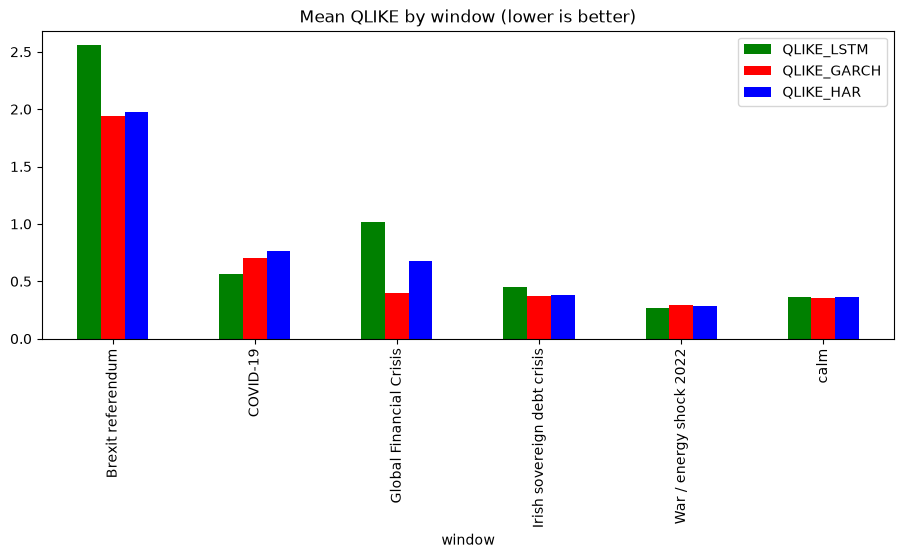

In [5]:
by_window.plot(kind='bar', figsize=(11, 4), color=['green', 'red', 'blue'], title='Mean QLIKE by window (lower is better)')

## Are the differences significant? (Diebold–Mariano, from notebook 13)

In [6]:
from numpy import sqrt
from scipy.stats import t


def dm_test(loss_a, loss_b):
    '''The Diebold-Mariano test of notebook 13 (negative difference = model A more accurate).'''
    d = loss_a - loss_b
    n = len(d)
    d_mean = d.mean()
    dc = d - d_mean
    long_run_variance = (dc * dc).sum() / n
    for k in [1, 2, 3, 4]:
        long_run_variance = long_run_variance + 2 * (dc * dc.shift(k)).sum() / n
    dm = d_mean / sqrt(long_run_variance / n)
    dm_hln = dm * sqrt((n + 1 - 10 + 20 / n) / n)
    p_value = 2 * t.sf(abs(dm_hln), df=n - 1)
    print('average difference =', round(d_mean, 4), '| DM =', round(dm_hln, 2), '| p-value =', round(p_value, 4))
    return d_mean, p_value

In [7]:
print('LSTM vs GARCH:')
diff_garch, p_garch = dm_test(results['QLIKE_LSTM'], results['QLIKE_GARCH'])
print('LSTM vs HAR:')
diff_har, p_har = dm_test(results['QLIKE_LSTM'], results['QLIKE_HAR'])

LSTM vs GARCH:
average difference = 0.0831 | DM = 3.01 | p-value = 0.0026
LSTM vs HAR:
average difference = 0.0489 | DM = 2.02 | p-value = 0.0436


## The verdict on H1
H1 is supported only if the LSTM's loss is **lower** (negative difference) **and** significant (p < 0.05) against **both** benchmarks.

In [8]:
if diff_garch < 0 and p_garch < 0.05 and diff_har < 0 and p_har < 0.05:
    print('H1 supported')
else:
    print('H1 NOT supported: the LSTM is not more accurate than both benchmarks')

H1 NOT supported: the LSTM is not more accurate than both benchmarks


The differences are positive and significant: over 2007–2023 the LSTM is significantly **less** accurate than GARCH (p = 0.003) and HAR (p = 0.04). This is a genuine finding because the hypothesis was written down before the results (pre-registration).